Saving portrait-white-man-isolated_53876-40306.avif to portrait-white-man-isolated_53876-40306.avif
Detected Faces, Eyes, and Smile


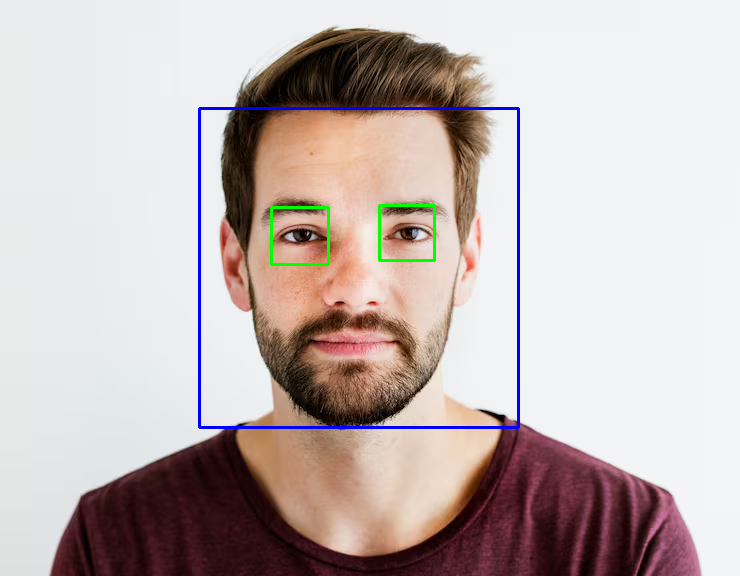

In [ ]:
# Install OpenCV
!pip install opencv-python-headless

import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load pre-trained Haar Cascade models
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

# Draw detections
for (x, y, w, h) in faces:
    # Face rectangle (blue)
    cv2.rectangle(img, (x,y), (x+w,y+h), (255,0,0), 2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    # Detect eyes
    eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 10)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex,ey), (ex+ew,ey+eh), (0,255,0), 2)

    # Detect smile
    smiles = smile_cascade.detectMultiScale(roi_gray, 1.7, 20)
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx,sy), (sx+sw,sy+sh), (0,0,255), 2)

# Display result
print("Detected Faces, Eyes, and Smile")
cv2_imshow(img)